# MovieLens 25M Brief Profile

Short exploratory notebook for the normalized parquet files used by `recsys-gen`.

Targets:
- `data/raw/movielens25m_interactions.parquet`
- `data/raw/movielens25m_items.parquet`

This notebook includes:
- fast Polars summaries for scale, quality, and activity
- temporal and metadata profiling
- an optional `ydata-profiling` HTML report when that package is installed


In [11]:
from pathlib import Path

import pandas as pd
import polars as pl

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    from ydata_profiling import ProfileReport
except ImportError:
    ProfileReport = None

pl.Config.set_tbl_rows(10)
pl.Config.set_tbl_cols(12)

INTERACTIONS_PATH = Path("../data/raw/movielens25m_interactions.parquet")
ITEMS_PATH = Path("../data/raw/movielens25m_items.parquet")
REPORT_DIR = Path("../reports/profiles")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

assert INTERACTIONS_PATH.exists(), INTERACTIONS_PATH
assert ITEMS_PATH.exists(), ITEMS_PATH

interactions = pl.read_parquet(INTERACTIONS_PATH)
items = pl.read_parquet(ITEMS_PATH)

print(INTERACTIONS_PATH)
print(ITEMS_PATH)
print(f"ydata_profiling available: {ProfileReport is not None}")


/Users/yao/projects/ml-playground/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


../data/raw/movielens25m_interactions.parquet
../data/raw/movielens25m_items.parquet
ydata_profiling available: True


In [12]:
interactions.head(5)

user_id,item_id,timestamp,target,event_type,rating
i64,i64,i64,i8,str,f64
1,5952,1147868053,1,"""rating""",4.0
1,2012,1147868068,1,"""rating""",2.5
1,2011,1147868079,1,"""rating""",2.5
1,1653,1147868097,1,"""rating""",4.0
1,1250,1147868414,1,"""rating""",4.0


In [13]:
items.head(5)

item_id,source_item_id,title,genres,tag_text
i64,str,str,str,str
1,"""1""","""Toy Story (1995)""","""Adventure|Animation|Children|C…","""2009 reissue in Stereoscopic 3…"
2,"""2""","""Jumanji (1995)""","""Adventure|Children|Fantasy""","""Adaptation of Book | CLV | Chi…"
3,"""3""","""Grumpier Old Men (1995)""","""Comedy|Romance""","""Ann Margaret | Burgess Meredit…"
4,"""4""","""Waiting to Exhale (1995)""","""Comedy|Drama|Romance""","""CLV | based on novel or book |…"
5,"""5""","""Father of the Bride Part II (1…","""Comedy""","""CLV | Comedy | Diane Keaton | …"


## Core summary

In [14]:
interaction_summary = interactions.select(
    pl.len().alias("rows"),
    pl.n_unique("user_id").alias("unique_users"),
    pl.n_unique("item_id").alias("unique_interacted_items"),
    pl.col("timestamp").min().alias("min_timestamp"),
    pl.col("timestamp").max().alias("max_timestamp"),
    pl.col("rating").mean().alias("mean_rating"),
    pl.col("rating").median().alias("median_rating"),
    pl.col("rating").std().alias("std_rating")
)

item_summary = items.select(
    pl.len().alias("item_rows"),
    pl.n_unique("item_id").alias("unique_item_ids"),
    pl.col("tag_text").is_not_null().sum().alias("items_with_tags")
)

summary = pl.concat([interaction_summary, item_summary], how="horizontal").with_columns(
    pl.from_epoch("min_timestamp", time_unit="s").alias("min_datetime_utc"),
    pl.from_epoch("max_timestamp", time_unit="s").alias("max_datetime_utc"),
    (pl.col("unique_interacted_items") / pl.col("unique_item_ids")).alias("catalog_coverage"),
    ((pl.col("rows") / (pl.col("unique_users") * pl.col("unique_interacted_items"))).alias("observed_matrix_density"))
)

summary

rows,unique_users,unique_interacted_items,min_timestamp,max_timestamp,mean_rating,…,unique_item_ids,items_with_tags,min_datetime_utc,max_datetime_utc,catalog_coverage,observed_matrix_density
u32,u32,u32,i64,i64,f64,…,u32,u32,datetime[μs],datetime[μs],f64,f64
25000095,162541,59047,789652009,1574327703,3.533854,…,62423,45251,1995-01-09 11:46:49,2019-11-21 09:15:03,0.945917,0.024811


## Schema, nulls, and duplicates

In [15]:
interaction_schema = pl.DataFrame({
    "column": interactions.columns,
    "dtype": [str(dtype) for dtype in interactions.dtypes],
    "null_count": interactions.null_count().row(0),
})

item_schema = pl.DataFrame({
    "column": items.columns,
    "dtype": [str(dtype) for dtype in items.dtypes],
    "null_count": items.null_count().row(0),
})

duplicate_summary = pl.DataFrame({
    "metric": [
        "duplicate_interaction_rows",
        "duplicate_user_item_timestamp_rows",
        "duplicate_item_rows",
    ],
    "value": [
        interactions.height - interactions.unique().height,
        interactions.height - interactions.unique(subset=["user_id", "item_id", "timestamp"]).height,
        items.height - items.unique(subset=["item_id"]).height,
    ],
})

interaction_schema, item_schema, duplicate_summary

(shape: (6, 3)
 ┌────────────┬─────────┬────────────┐
 │ column     ┆ dtype   ┆ null_count │
 │ ---        ┆ ---     ┆ ---        │
 │ str        ┆ str     ┆ i64        │
 ╞════════════╪═════════╪════════════╡
 │ user_id    ┆ Int64   ┆ 0          │
 │ item_id    ┆ Int64   ┆ 0          │
 │ timestamp  ┆ Int64   ┆ 0          │
 │ target     ┆ Int8    ┆ 0          │
 │ event_type ┆ String  ┆ 0          │
 │ rating     ┆ Float64 ┆ 0          │
 └────────────┴─────────┴────────────┘,
 shape: (5, 3)
 ┌────────────────┬────────┬────────────┐
 │ column         ┆ dtype  ┆ null_count │
 │ ---            ┆ ---    ┆ ---        │
 │ str            ┆ str    ┆ i64        │
 ╞════════════════╪════════╪════════════╡
 │ item_id        ┆ Int64  ┆ 0          │
 │ source_item_id ┆ String ┆ 0          │
 │ title          ┆ String ┆ 0          │
 │ genres         ┆ String ┆ 0          │
 │ tag_text       ┆ String ┆ 17172      │
 └────────────────┴────────┴────────────┘,
 shape: (3, 2)
 ┌─────────────────────

## Rating distribution

In [16]:
rating_dist = interactions.group_by("rating").len().sort("rating")
rating_dist

rating,len
f64,u32
0.5,393068
1.0,776815
1.5,399490
2.0,1640868
2.5,1262797
3.0,4896928
3.5,3177318
4.0,6639798
4.5,2200539


In [17]:
rating_stats = interactions.select(
    pl.col("rating").quantile(0.01).alias("p01"),
    pl.col("rating").quantile(0.10).alias("p10"),
    pl.col("rating").quantile(0.25).alias("p25"),
    pl.col("rating").quantile(0.50).alias("p50"),
    pl.col("rating").quantile(0.75).alias("p75"),
    pl.col("rating").quantile(0.90).alias("p90"),
    pl.col("rating").quantile(0.99).alias("p99")
)
rating_stats

p01,p10,p25,p50,p75,p90,p99
f64,f64,f64,f64,f64,f64,f64
0.5,2.0,3.0,3.5,4.0,5.0,5.0


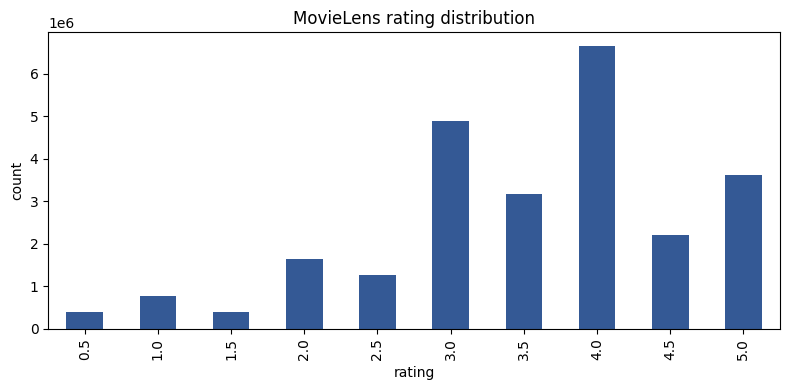

In [18]:
if plt is None:
    print("matplotlib is not installed; skipping chart")
else:
    pdf = rating_dist.to_pandas()
    ax = pdf.plot.bar(x="rating", y="len", legend=False, figsize=(8, 4), color="#345995")
    ax.set_title("MovieLens rating distribution")
    ax.set_xlabel("rating")
    ax.set_ylabel("count")
    plt.tight_layout()


## User and item activity

In [19]:
user_activity = interactions.group_by("user_id").len()
item_activity = interactions.group_by("item_id").len()

activity_profile = pl.DataFrame({
    "metric": [
        "user_interactions_min",
        "user_interactions_p50",
        "user_interactions_p90",
        "user_interactions_p99",
        "user_interactions_max",
        "item_interactions_min",
        "item_interactions_p50",
        "item_interactions_p90",
        "item_interactions_p99",
        "item_interactions_max",
    ],
    "value": [
        user_activity["len"].min(),
        user_activity["len"].quantile(0.50),
        user_activity["len"].quantile(0.90),
        user_activity["len"].quantile(0.99),
        user_activity["len"].max(),
        item_activity["len"].min(),
        item_activity["len"].quantile(0.50),
        item_activity["len"].quantile(0.90),
        item_activity["len"].quantile(0.99),
        item_activity["len"].max(),
    ],
})

activity_profile

TypeError: unexpected value while building Series of type Int64; found value of type Float64: 71.0

Hint: Try setting `strict=False` to allow passing data with mixed types.

In [ ]:
top_users = user_activity.sort("len", descending=True).head(10)
top_items = item_activity.sort("len", descending=True).head(10).join(
    items.select("item_id", "title", "genres"),
    on="item_id",
    how="left",
)

top_users, top_items

## Temporal profile

In [ ]:
temporal_profile = (
    interactions
    .with_columns(pl.from_epoch("timestamp", time_unit="s").alias("datetime_utc"))
    .with_columns(
        pl.col("datetime_utc").dt.year().alias("year"),
        pl.col("datetime_utc").dt.month().alias("month"),
    )
)

yearly_counts = temporal_profile.group_by("year").len().sort("year")
monthly_counts = temporal_profile.group_by(["year", "month"]).len().sort(["year", "month"])

yearly_counts.head(20), monthly_counts.head(20)

In [ ]:
if plt is None:
    print("matplotlib is not installed; skipping chart")
else:
    pdf = yearly_counts.to_pandas()
    ax = pdf.plot.line(x="year", y="len", figsize=(9, 4), color="#c75146")
    ax.set_title("Interactions by year")
    ax.set_xlabel("year")
    ax.set_ylabel("count")
    plt.tight_layout()


## Metadata profile

In [ ]:
genre_counts = (
    items
    .with_columns(pl.col("genres").str.split("|").alias("genre_list"))
    .explode("genre_list")
    .filter(pl.col("genre_list").is_not_null() & (pl.col("genre_list") != ""))
    .group_by("genre_list")
    .len()
    .sort("len", descending=True)
)

tag_profile = items.select(
    pl.col("tag_text").is_not_null().mean().alias("share_with_tag_text"),
    pl.col("tag_text").str.len_chars().mean().alias("avg_tag_text_length")
)

genre_counts.head(15), tag_profile

## Optional ydata-profiling report

Install first if needed:

```bash
uv add ydata-profiling
```

For large tables, sample before profiling to keep the report usable.


In [ ]:
if ProfileReport is None:
    print("ydata-profiling is not installed. Run: uv add ydata-profiling")
else:
    sampled = interactions.sample(fraction=0.02, seed=7).to_pandas()
    report = ProfileReport(sampled, title="MovieLens 25M Sample Profile", minimal=True)
    report_path = REPORT_DIR / "movielens25m_profile_report.html"
    report.to_file(report_path)
    print(report_path)
    report

## Quick observations template

Use this section after running the notebook:

- The normalized interaction table is dense enough for retrieval experiments and keeps the original explicit `rating` signal.
- The item table is larger than the interacted-item set, so some catalog items are cold relative to the ratings table.
- User and item activity are long-tailed, which matters for filtering thresholds and evaluation stability.
- Genre and tag metadata make MovieLens the richest item side-information source among the currently normalized datasets.
